In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

products = [
    "Laptop", "Smartphone", "Headphones", "Keyboard",
    "Mouse", "Monitor", "Tablet", "Smartwatch",
    "Printer", "USB Drive"
]

categories = {
    "Laptop": "Electronics",
    "Smartphone": "Electronics",
    "Headphones": "Accessories",
    "Keyboard": "Accessories",
    "Mouse": "Accessories",
    "Monitor": "Electronics",
    "Tablet": "Electronics",
    "Smartwatch": "Wearables",
    "Printer": "Electronics",
    "USB Drive": "Accessories"
}

stores = ["Chennai", "Coimbatore", "Madurai", "Trichy", "Salem"]

payment_methods = ["UPI", "Credit Card", "Debit Card", "Cash"]

data = []

for i in range(n):
    product = np.random.choice(products)
    quantity = np.random.randint(1, 6)
    price = np.random.randint(500, 60000)

    data.append([
        f"R{i+1:04}",
        pd.Timestamp("2025-01-01") +
        pd.Timedelta(days=np.random.randint(0, 365)),
        product,
        categories[product],
        np.random.choice(stores),
        quantity,
        price,
        quantity * price,
        np.random.choice(payment_methods)
    ])

df = pd.DataFrame(data, columns=[
    "Order_ID",
    "Date",
    "Product",
    "Category",
    "Store",
    "Quantity",
    "Unit_Price",
    "Total_Sales",
    "Payment_Method"
])

df.head()

,Order_ID,Date,Product,Category,Store,Quantity,Unit_Price,Total_Sales,Payment_Method
0,R0001,2025-09-28,Tablet,Electronics,Madurai,4,1360,5440,Cash
1,R0002,2025-08-03,Mouse,Accessories,Madurai,2,17350,34700,Debit Card
2,R0003,2025-12-26,Smartwatch,Wearables,Madurai,5,44631,223155,Credit Card
3,R0004,2025-07-11,Mouse,Accessories,Trichy,2,56601,113202,UPI
4,R0005,2025-01-22,Laptop,Electronics,Salem,4,20269,81076,Cash


In [4]:
df.shape

(1000, 9)

In [5]:
df.describe()


,Date,Quantity,Unit_Price,Total_Sales
count,1000,1000.000000,1000.000000,1000.000000
mean,2025-07-05 02:00:57.600000,2.985000,30267.716000,89452.775000
min,2025-01-01 00:00:00,1.000000,509.000000,509.000000
25%,2025-04-08 00:00:00,2.000000,16776.500000,34936.000000
50%,2025-07-06 00:00:00,3.000000,28916.000000,70782.000000
75%,2025-10-03 06:00:00,4.000000,45085.750000,127140.750000
max,2025-12-31 00:00:00,5.000000,59946.000000,297710.000000
std,NaN,1.406682,16899.163242,69451.775992


In [6]:
df.isnull().sum()


,0
Order_ID,0
Date,0
Product,0
Category,0
Store,0
Quantity,0
Unit_Price,0
Total_Sales,0
Payment_Method,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

,0
Order_ID,object
Date,datetime64[ns]
Product,object
Category,object
Store,object
Quantity,int64
Unit_Price,int64
Total_Sales,int64
Payment_Method,object


In [9]:
total_revenue = df["Total_Sales"].sum()

print("Total Revenue: ₹", total_revenue)

Total Revenue: ₹ 89452775


In [10]:
total_quantity = df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 2985


In [11]:
product_sales = df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)

print(product_sales)

Product
Laptop        11067809
Mouse          9977785
Headphones     9680944
Tablet         9679264
Smartphone     9085696
Smartwatch     8609838
Monitor        8020689
Keyboard       7906416
USB Drive      7906187
Printer        7518147
Name: Total_Sales, dtype: int64


In [12]:
category_sales = df.groupby("Category")["Total_Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Electronics    45371605
Accessories    35471332
Wearables       8609838
Name: Total_Sales, dtype: int64


In [13]:
df.isnull().sum()

,0
Order_ID,0
Date,0
Product,0
Category,0
Store,0
Quantity,0
Unit_Price,0
Total_Sales,0
Payment_Method,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.dtypes

,0
Order_ID,object
Date,datetime64[ns]
Product,object
Category,object
Store,object
Quantity,int64
Unit_Price,int64
Total_Sales,int64
Payment_Method,object


In [16]:
# Key Retail KPIs

total_revenue = df["Total_Sales"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order_ID"].nunique()
average_order_value = df["Total_Sales"].mean()

print("Total Revenue       : ₹", total_revenue)
print("Total Quantity Sold : ", total_quantity)
print("Total Orders        : ", total_orders)
print("Average Order Value : ₹", round(average_order_value, 2))

Total Revenue       : ₹ 89452775
Total Quantity Sold :  2985
Total Orders        :  1000
Average Order Value : ₹ 89452.78


In [17]:
category_sales = (
    df.groupby("Category")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Electronics    45371605
Accessories    35471332
Wearables       8609838
Name: Total_Sales, dtype: int64


In [18]:
# Create Month column
df["Month"] = df["Date"].dt.month_name()

# Calculate monthly sales
monthly_sales = df.groupby("Month")["Total_Sales"].sum()

print(monthly_sales)

Month
April        7101559
August       7991920
December     8670305
February     6642706
January      8098287
July         7340429
June         7797510
March        5633612
May          6996341
November     8000980
October      7416117
September    7763009
Name: Total_Sales, dtype: int64


In [19]:
# Arrange months in correct order

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales = (
    df.groupby("Month")["Total_Sales"]
    .sum()
    .reindex(month_order)
)

print(monthly_sales)

Month
January      8098287
February     6642706
March        5633612
April        7101559
May          6996341
June         7797510
July         7340429
August       7991920
September    7763009
October      7416117
November     8000980
December     8670305
Name: Total_Sales, dtype: int64


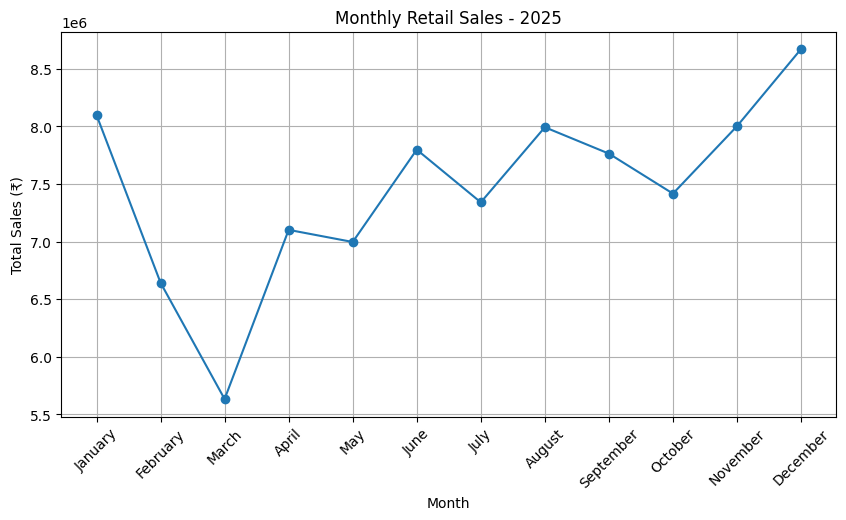

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Retail Sales - 2025")
plt.xlabel("Month")
plt.ylabel("Total Sales (₹)")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

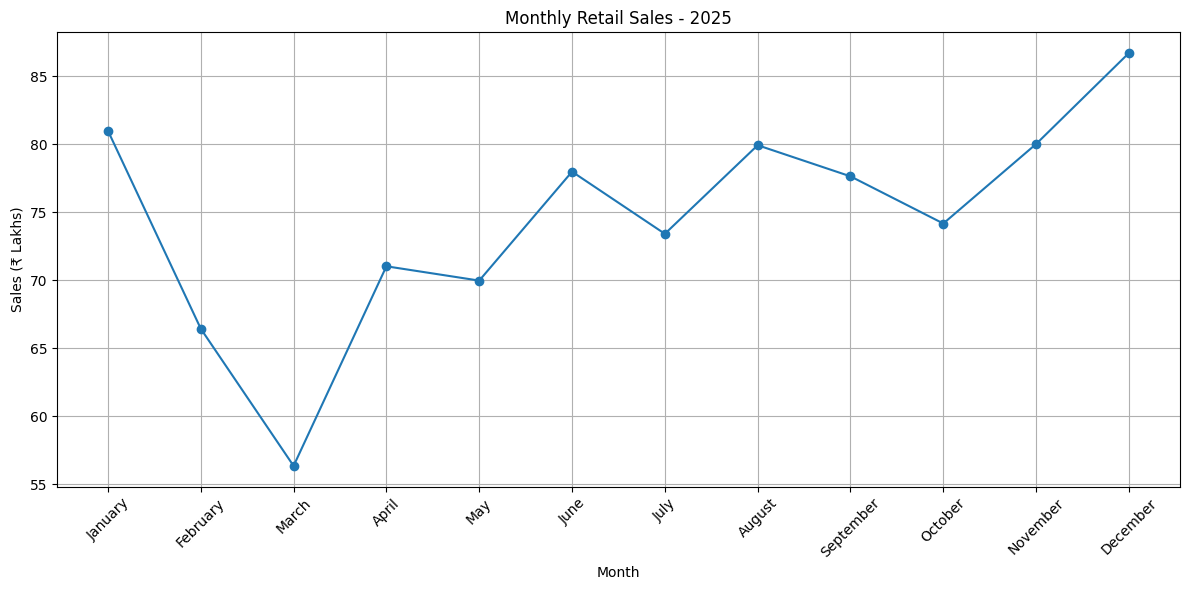

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values / 100000,
    marker="o"
)

plt.title("Monthly Retail Sales - 2025")
plt.xlabel("Month")
plt.ylabel("Sales (₹ Lakhs)")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
product_sales = (
    df.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(product_sales)

Product
Laptop        11067809
Mouse          9977785
Headphones     9680944
Tablet         9679264
Smartphone     9085696
Smartwatch     8609838
Monitor        8020689
Keyboard       7906416
USB Drive      7906187
Printer        7518147
Name: Total_Sales, dtype: int64


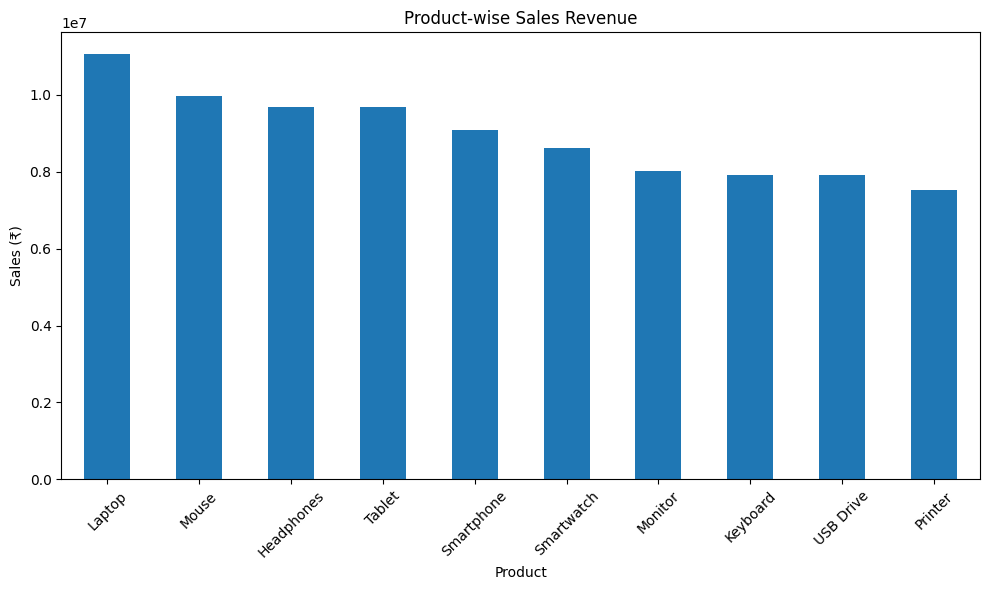

In [23]:
plt.figure(figsize=(10, 6))

product_sales.plot(kind="bar")

plt.title("Product-wise Sales Revenue")
plt.xlabel("Product")
plt.ylabel("Sales (₹)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [24]:
product_sales = (
    df.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(product_sales)

Product
Laptop        11067809
Mouse          9977785
Headphones     9680944
Tablet         9679264
Smartphone     9085696
Smartwatch     8609838
Monitor        8020689
Keyboard       7906416
USB Drive      7906187
Printer        7518147
Name: Total_Sales, dtype: int64


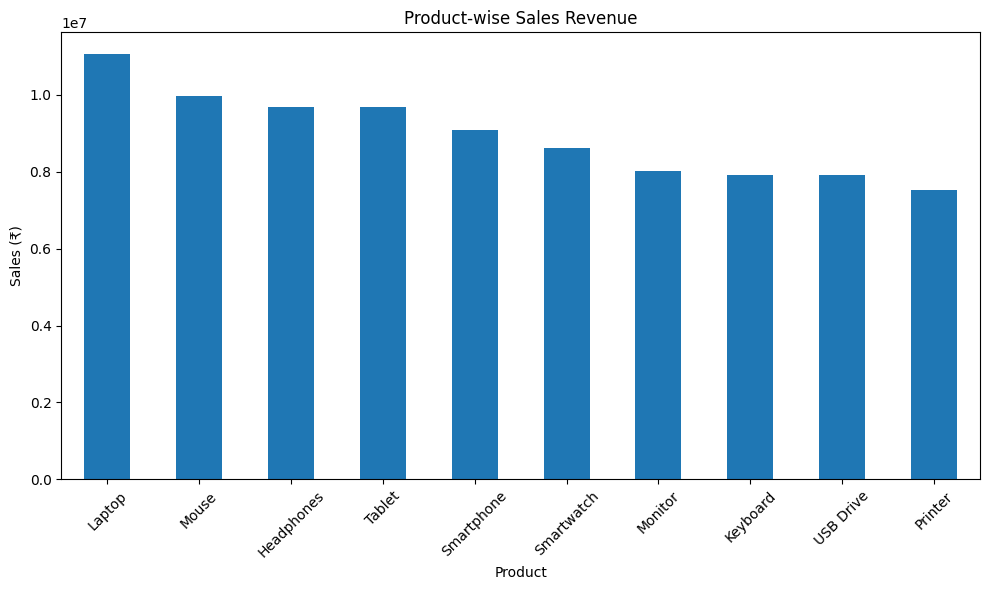

In [25]:
plt.figure(figsize=(10, 6))

product_sales.plot(kind="bar")

plt.title("Product-wise Sales Revenue")
plt.xlabel("Product")
plt.ylabel("Sales (₹)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

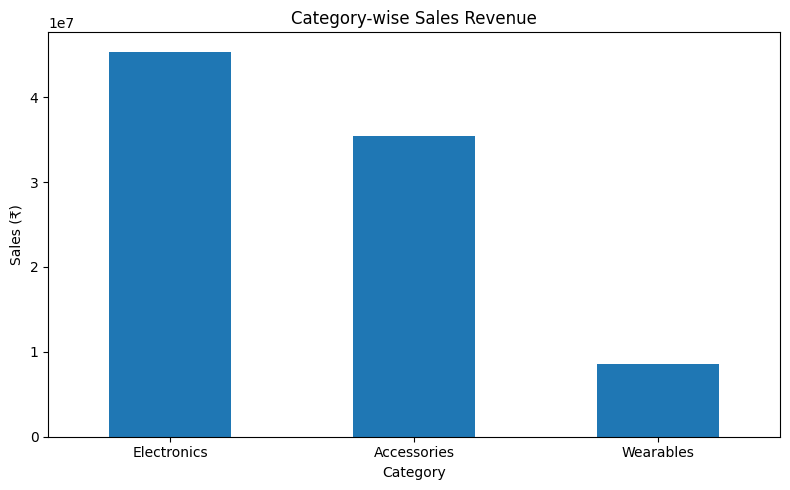

In [26]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Category-wise Sales Revenue")
plt.xlabel("Category")
plt.ylabel("Sales (₹)")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [27]:
store_sales = (
    df.groupby("Store")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(store_sales)

Store
Trichy        19042711
Salem         17968757
Madurai       17509167
Chennai       17497340
Coimbatore    17434800
Name: Total_Sales, dtype: int64


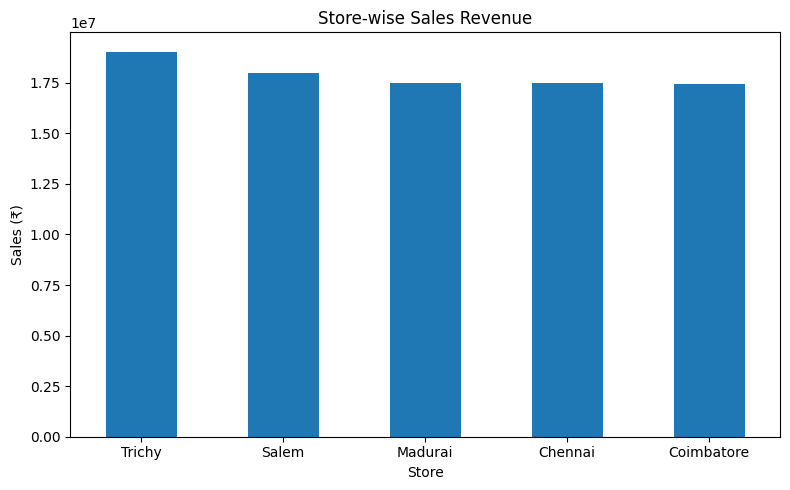

In [28]:
plt.figure(figsize=(8, 5))

store_sales.plot(kind="bar")

plt.title("Store-wise Sales Revenue")
plt.xlabel("Store")
plt.ylabel("Sales (₹)")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [29]:
payment_counts = df["Payment_Method"].value_counts()

print(payment_counts)

Payment_Method
Debit Card     276
Credit Card    245
Cash           240
UPI            239
Name: count, dtype: int64


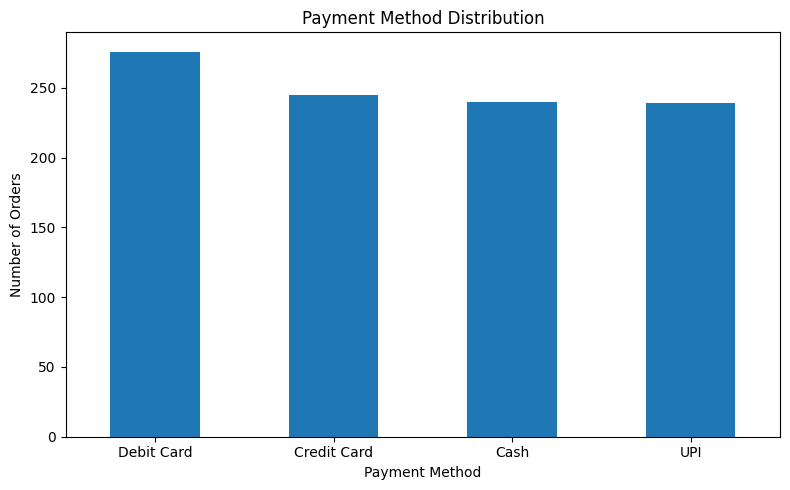

In [30]:
plt.figure(figsize=(8, 5))

payment_counts.plot(kind="bar")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [31]:
payment_sales = (
    df.groupby("Payment_Method")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(payment_sales)

Payment_Method
Debit Card     25731271
UPI            23133304
Cash           20937213
Credit Card    19650987
Name: Total_Sales, dtype: int64


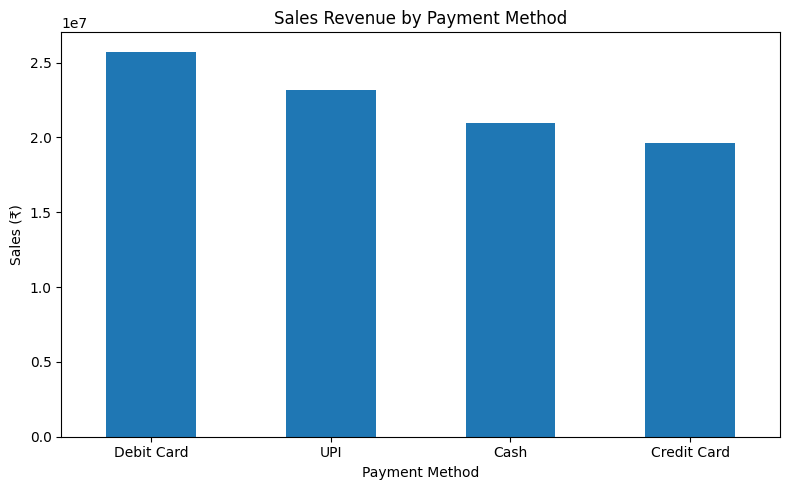

In [32]:
plt.figure(figsize=(8, 5))

payment_sales.plot(kind="bar")

plt.title("Sales Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Sales (₹)")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [33]:
store_category_sales = pd.pivot_table(
    df,
    values="Total_Sales",
    index="Store",
    columns="Category",
    aggfunc="sum"
)

print(store_category_sales)

Category    Accessories  Electronics  Wearables
Store                                          
Chennai         7266740      8655196    1575404
Coimbatore      7781728      8768797     884275
Madurai         6267676      9300655    1940836
Salem           6851584      9230472    1886701
Trichy          7303604      9416485    2322622


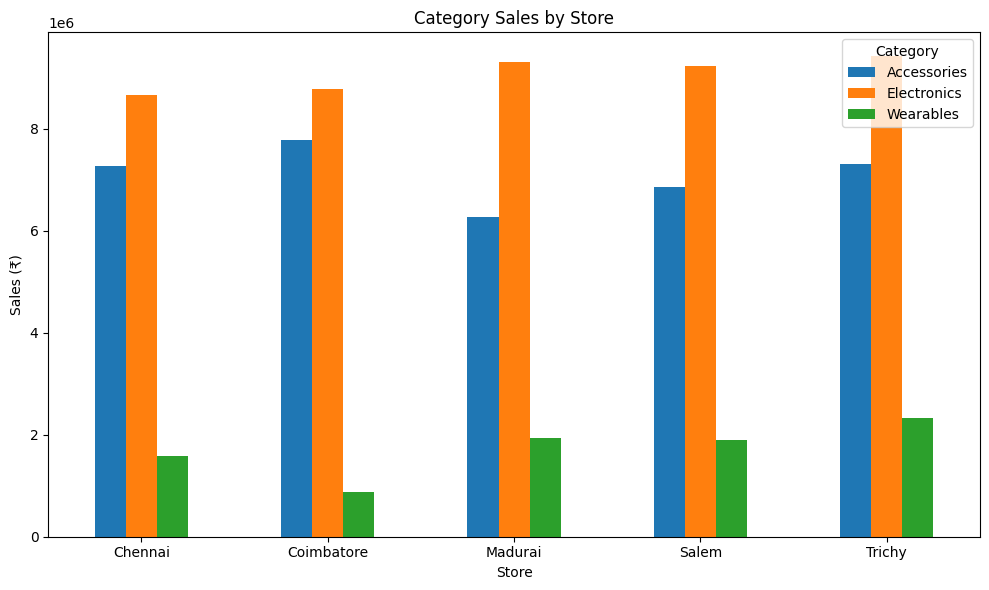

In [34]:
store_category_sales.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Category Sales by Store")
plt.xlabel("Store")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [35]:
best_store = store_sales.idxmax()
best_store_sales = store_sales.max()

print("Highest Revenue Store:", best_store)
print("Sales Revenue: ₹", best_store_sales)

Highest Revenue Store: Trichy
Sales Revenue: ₹ 19042711


In [36]:
lowest_store = store_sales.idxmin()
lowest_store_sales = store_sales.min()

print("Lowest Revenue Store:", lowest_store)
print("Sales Revenue: ₹", lowest_store_sales)

Lowest Revenue Store: Coimbatore
Sales Revenue: ₹ 17434800


In [37]:
best_product = product_sales.idxmax()
best_product_sales = product_sales.max()

print("Highest Revenue Product:", best_product)
print("Sales Revenue: ₹", best_product_sales)

Highest Revenue Product: Laptop
Sales Revenue: ₹ 11067809


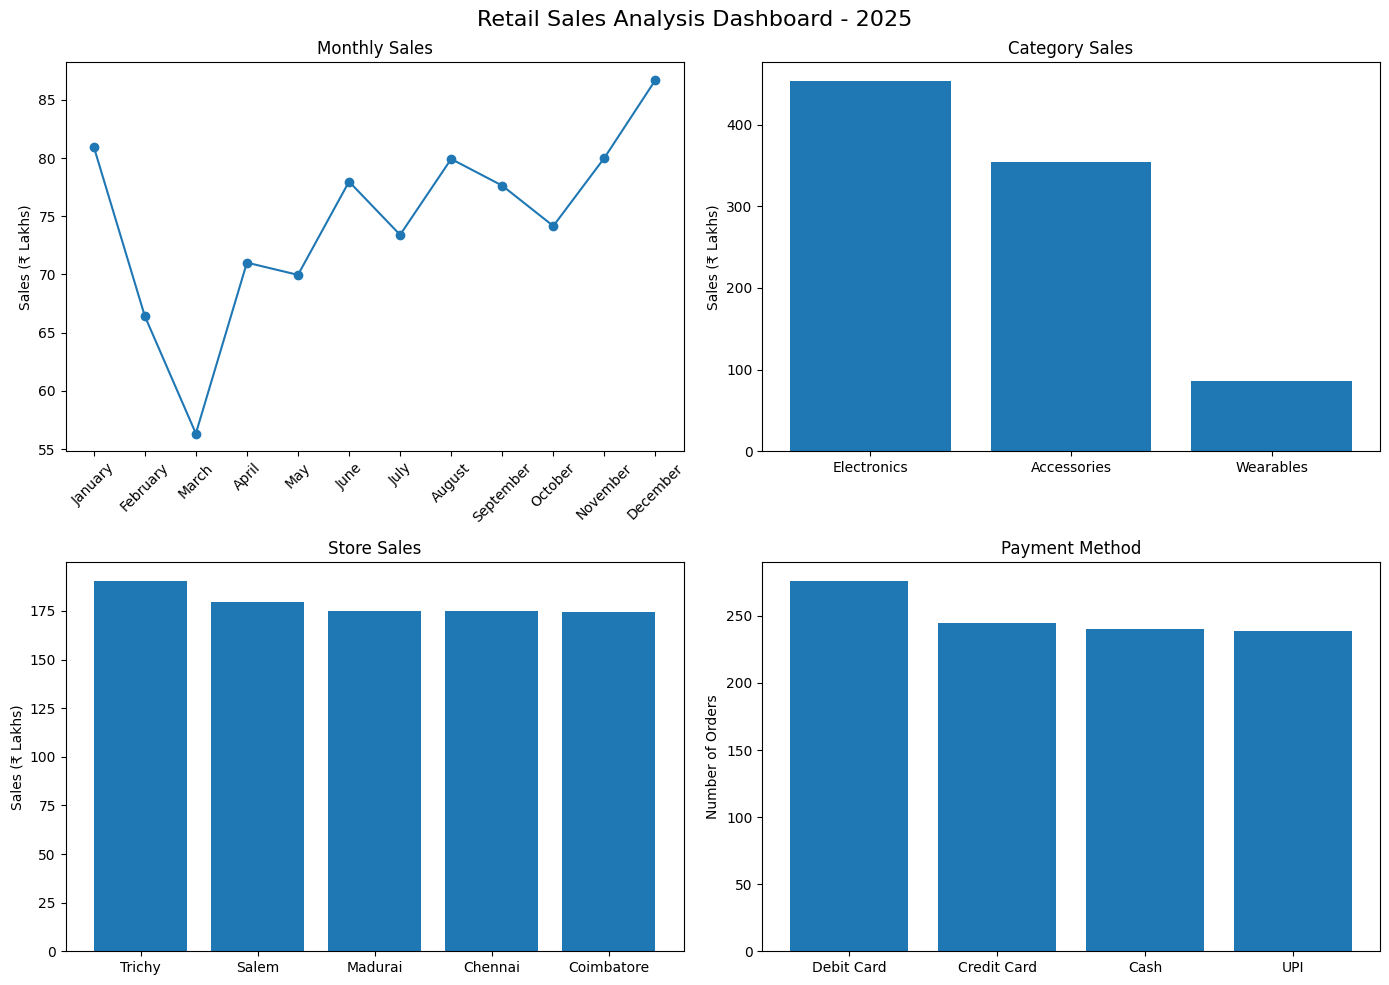

In [38]:
# RETAIL SALES KPI DASHBOARD

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Monthly Sales
axes[0, 0].plot(
    monthly_sales.index,
    monthly_sales.values / 100000,
    marker="o"
)
axes[0, 0].set_title("Monthly Sales")
axes[0, 0].set_ylabel("Sales (₹ Lakhs)")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Category Sales
axes[0, 1].bar(
    category_sales.index,
    category_sales.values / 100000
)
axes[0, 1].set_title("Category Sales")
axes[0, 1].set_ylabel("Sales (₹ Lakhs)")

# 3. Store Sales
axes[1, 0].bar(
    store_sales.index,
    store_sales.values / 100000
)
axes[1, 0].set_title("Store Sales")
axes[1, 0].set_ylabel("Sales (₹ Lakhs)")

# 4. Payment Methods
axes[1, 1].bar(
    payment_counts.index,
    payment_counts.values
)
axes[1, 1].set_title("Payment Method")
axes[1, 1].set_ylabel("Number of Orders")

plt.suptitle(
    "Retail Sales Analysis Dashboard - 2025",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [39]:
print("===== RETAIL BUSINESS INSIGHTS =====")

print("\nTotal Revenue:")
print("₹", total_revenue)

print("\nTotal Orders:")
print(total_orders)

print("\nTotal Quantity Sold:")
print(total_quantity)

print("\nAverage Order Value:")
print("₹", round(average_order_value, 2))

print("\nHighest Revenue Category:")
print(category_sales.idxmax())

print("Category Revenue:")
print("₹", category_sales.max())

print("\nHighest Revenue Store:")
print(store_sales.idxmax())

print("Store Revenue:")
print("₹", store_sales.max())

print("\nHighest Revenue Product:")
print(product_sales.idxmax())

print("Product Revenue:")
print("₹", product_sales.max())

print("\nHighest Sales Month:")
print(monthly_sales.idxmax())

print("Monthly Revenue:")
print("₹", monthly_sales.max())

print("\nLowest Sales Month:")
print(monthly_sales.idxmin())

print("Monthly Revenue:")
print("₹", monthly_sales.min())

===== RETAIL BUSINESS INSIGHTS =====

Total Revenue:
₹ 89452775

Total Orders:
1000

Total Quantity Sold:
2985

Average Order Value:
₹ 89452.78

Highest Revenue Category:
Electronics
Category Revenue:
₹ 45371605

Highest Revenue Store:
Trichy
Store Revenue:
₹ 19042711

Highest Revenue Product:
Laptop
Product Revenue:
₹ 11067809

Highest Sales Month:
December
Monthly Revenue:
₹ 8670305

Lowest Sales Month:
March
Monthly Revenue:
₹ 5633612


In [41]:
df.to_csv("retail_sales_data.csv", index=False)

print("Retail dataset saved successfully!")

Retail dataset saved successfully!


In [42]:
df.to_csv("retail_sales_data.csv", index=False)

print("CSV created successfully!")

CSV created successfully!
